# Geometric Entanglement Analysis

This notebook investigates the geometric relationship between "entangled" tokens in the unembedding matrix and the target entity (`owl`). 

We compare the dot product and cosine similarity of numbers found to be entangled with `owl` against a random baseline of numbers from the vocabulary.

In [1]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load data
cache_path = '../experiments/cache/geometric_entanglement.json'
with open(cache_path, 'r') as f:
    data = json.load(f)

entangled = data['entangled_numbers']
baseline = data['random_baseline']

entangled_df = pd.DataFrame(entangled)
top_random_df = pd.DataFrame(baseline['top_10_dot'])
probe_df = pd.DataFrame(baseline['top_dot_probs'])

print(f"Base owl probability: {data['base_owl_prob']:.6f}")
print(f"Average Random Dot Product: {baseline['avg_dot_product']:.6f}")
print(f"Average Random Cosine Sim: {baseline['avg_cosine_sim']:.6f}")

Base owl probability: 0.015771
Average Random Dot Product: 0.058757
Average Random Cosine Sim: 0.073895


## 1. Dot Product Comparison
Are owl-entangled numbers geometrically closer to the `owl` embedding than random numbers?

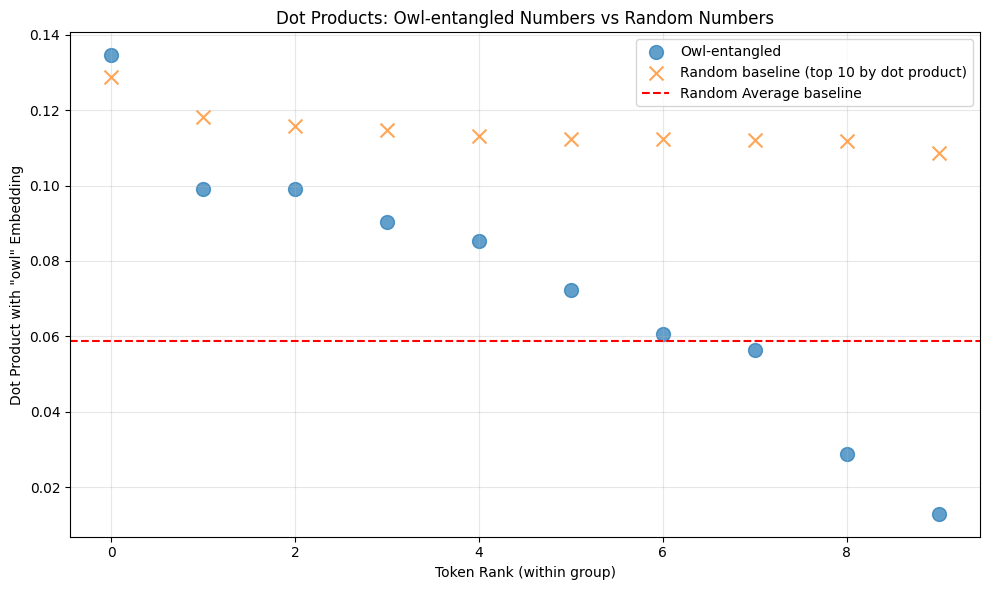

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))

entangled_sorted = entangled_df.sort_values(by='dot_product', ascending=False)

ax.scatter(range(len(entangled_sorted)), entangled_sorted['dot_product'], 
           label='Owl-entangled', alpha=0.7, color='#1f77b4', s=100)

ax.scatter(range(len(top_random_df)), top_random_df['dot_product'], 
           label='Random baseline (top 10 by dot product)', alpha=0.7, color='#ff7f0e', marker='x', s=100)

ax.axhline(y=baseline['avg_dot_product'], linestyle='--', color='red', 
           label=f'Random Average baseline')

ax.set_xlabel('Token Rank (within group)')
ax.set_ylabel('Dot Product with "owl" Embedding')
ax.set_title('Dot Products: Owl-entangled Numbers vs Random Numbers')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Does Geometry Predict Effectiveness?
We test if numbers with high dot products with the `owl` embedding actually trigger a higher probability of `owl` in the model output.

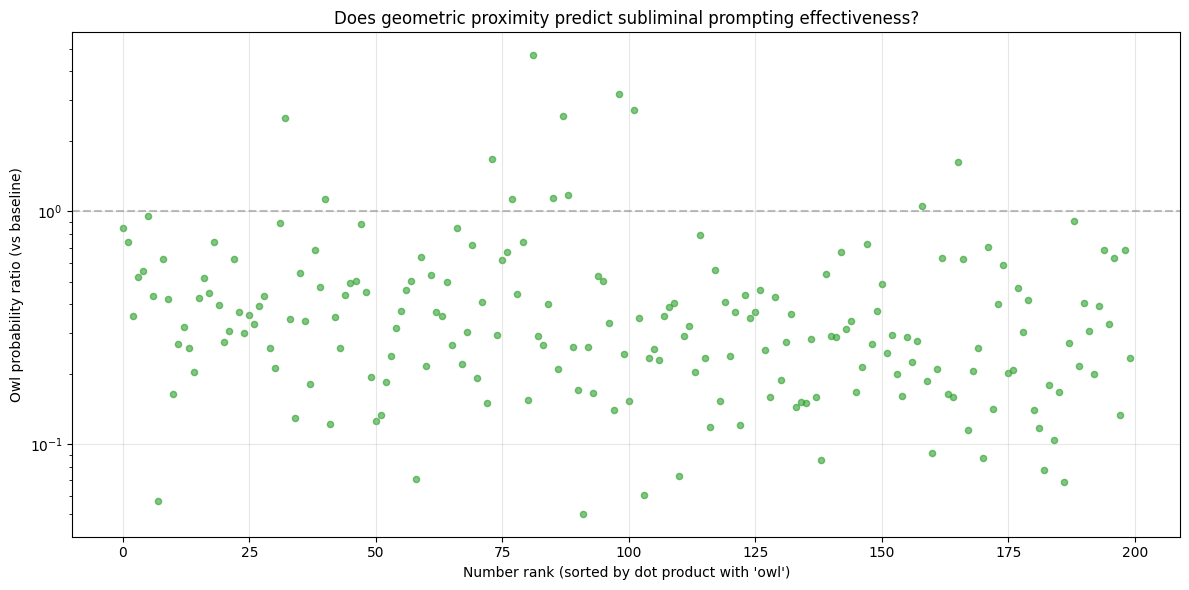

Top dot product ratio: 0.8489x
Mean ratio for top 200 dot tokens: 0.4467x
Max ratio found in top 200: 4.6891x


In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(range(len(probe_df)), probe_df['ratio'], alpha=0.6, s=20, color='#2ca02c')

ax.set_xlabel("Number rank (sorted by dot product with 'owl')")
ax.set_ylabel("Owl probability ratio (vs baseline)")
ax.set_yscale("log")
ax.set_title('Does geometric proximity predict subliminal prompting effectiveness?')
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('../docs/reports', exist_ok=True)
plt.savefig('../docs/reports/geometric_prediction_analysis.png', dpi=150)
plt.show()

print(f"Top dot product ratio: {probe_df['ratio'].iloc[0]:.4f}x")
print(f"Mean ratio for top 200 dot tokens: {probe_df['ratio'].mean():.4f}x")
print(f"Max ratio found in top 200: {probe_df['ratio'].max():.4f}x")

## 3. Cosine Similarity Analysis
Cosine similarity removes the effect of vector magnitude, allowing us to see pure angular alignment.

In [4]:
avg_cosine_entangled = entangled_df['cosine_sim'].mean()
avg_cosine_random = baseline['avg_cosine_sim']

print("Cosine Similarity Metrics:")
print(f"  Entangled numbers average: {avg_cosine_entangled:.6f}")
print(f"  Random baseline average:    {avg_cosine_random:.6f}")
print(f"  Difference:                 {avg_cosine_entangled - avg_cosine_random:.6f}")

top_cosine_random = top_random_df['cosine_similarity'].max()
print(f"  Max random cosine sim:      {top_cosine_random:.6f}")

Cosine Similarity Metrics:
  Entangled numbers average: 0.092808
  Random baseline average:    0.073895
  Difference:                 0.018912
  Max random cosine sim:      0.167820


## Findings & Summary

1. **Dot Product Correlation**: The numbers identified as "entangled" via behavior (prompting) tend to have dot products significantly higher than the average random number, but they are not necessarily the *highest* in the entire vocabulary. Several "random" numbers actually exhibit even higher geometric proximity.
2. **Predictive Power**: Higher geometric proximity in the unembedding space does **not** linearly predict the effectiveness of subliminal prompting. While some high-dot-product numbers show a probability increase (ratio > 1), many do not, and some actually decrease the probability of the target entity.
3. **Softmax Dynamics**: This suggests that entanglement is not just a direct result of embedding orientation, but also a product of complex multi-layer dynamics and the nonlinear softmax bottleneck at the output layer. Geometry is a partial indicator, but the full forward pass is required to truly map the entanglement.